In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_raw = pd.read_csv("/content/Dataset.csv")

print("Dimensiones:", df_raw.shape)
print("\nColumnas:", df_raw.columns.tolist())
print("\nTipos de datos:")
print(df_raw.dtypes)
print("\nPrimeras filas:")
df_raw.head(10)

Dimensiones: (22260, 13)

Columnas: ['Source', 'Destination', 'Time', 'frame length', 'flow lengths', 'flow bits', 'Port number', 'Protocol', 'Source port number', 'port 1 status', 'port 2 status', 'port 3 status', 'routing_interface']

Tipos de datos:
Source                 object
Destination            object
Time                  float64
frame length            int64
flow lengths            int64
flow bits               int64
Port number             int64
Protocol               object
Source port number     object
port 1 status          object
port 2 status          object
port 3 status          object
routing_interface      object
dtype: object

Primeras filas:


,Source,Destination,Time,frame length,flow lengths,flow bits,Port number,Protocol,Source port number,port 1 status,port 2 status,port 3 status,routing_interface
0,25.45.123.210/24,201.0.113.19/24,5.754884,186,144,1488,443,TCP,GigabitEthernet0/0,up,up,up,GigabitEthernet2/0
1,37.201.76.99/24,185.44.17.238/24,5.797261,733,691,5864,3478,UDP,GigabitEthernet0/0,up,up,up,GigabitEthernet1/0
2,25.45.123.210/24,185.44.17.238/24,5.828625,871,829,6968,443,TCP,GigabitEthernet0/0,up,up,up,GigabitEthernet1/0
3,201.0.113.19/24,37.201.76.99/24,5.860471,771,729,6168,8802,UDP,GigabitEthernet2/0,up,down,up,GigabitEthernet0/0
4,37.201.76.99/24,201.0.113.19/24,5.935580,918,876,7344,25102,UDP,GigabitEthernet0/0,up,down,up,GigabitEthernet2/0
5,201.0.113.19/24,68.151.104.83/24,5.966334,664,622,5312,56009,UDP,GigabitEthernet1/0,up,up,up,GigabitEthernet0/0
6,185.44.17.238/24,37.201.76.99/24,6.078077,806,764,6448,3478,UDP,GigabitEthernet1/0,up,up,up,GigabitEthernet0/0
7,37.201.76.99/24,102.67.88.14/24,6.119762,166,124,1328,53875,UDP,GigabitEthernet0/0,up,down,down,GigabitEthernet0/0-TI-LFA
8,201.0.113.19/24,25.45.123.210/24,6.172408,845,803,6760,26541,UDP,GigabitEthernet1/0,up,up,down,GigabitEthernet0/0
9,68.151.104.83/24,201.0.113.19/24,6.213635,831,789,6648,3478,UDP,GigabitEthernet0/0,up,up,up,GigabitEthernet1/0


Tiempo mínimo: 3.603817
Tiempo máximo: 147.159739
Duración total (segundos): 143.555922

Estadísticas de 'flow bits':
count    22260.000000
mean      5231.881402
std       2638.459354
min        480.000000
25%       3056.000000
50%       5040.000000
75%       7120.000000
max      12016.000000
Name: flow bits, dtype: float64


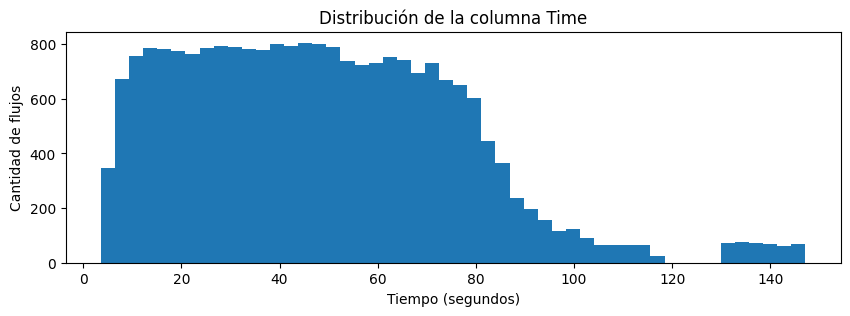

In [2]:
# revision rango temporal y orden por tiempo
df_raw = df_raw.sort_values("Time").reset_index(drop=True)

print("Tiempo mínimo:", df_raw["Time"].min())
print("Tiempo máximo:", df_raw["Time"].max())
print("Duración total (segundos):", df_raw["Time"].max() - df_raw["Time"].min())
print("\nEstadísticas de 'flow bits':")
print(df_raw["flow bits"].describe())

# vista rapida de distribucion de tiempos
plt.figure(figsize=(10, 3))
plt.hist(df_raw["Time"], bins=50)
plt.title("Distribución de la columna Time")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Cantidad de flujos")
plt.show()

puntos en la serie: 1298
   time_bin  total_bits
0       0.0        3904
1       0.3        1752
2       0.4       15904
3       0.5       29240
4       0.6       37592
5       0.7       33104
6       0.8       57016
7       0.9       46424
8       1.0       69168
9       1.1       64296


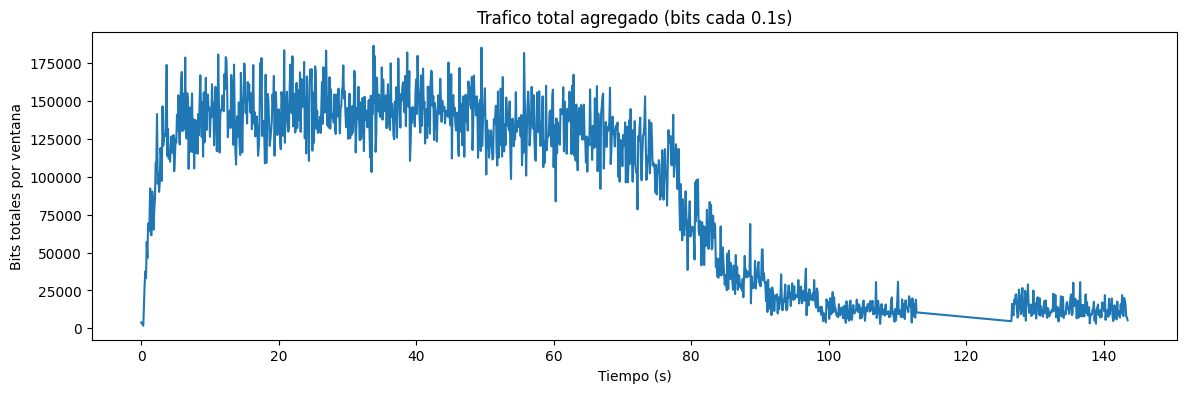

In [3]:
# el dataset viene con cada fila siendo un flujo individual, necesito juntarlos en el tiempo
# la duracion total es de solo ~143 segundos asi que voy a usar bins chiquitos de 0.1s
df_raw["time_rel"] = df_raw["Time"] - df_raw["Time"].min()  # que empiece desde 0

bin_size = 0.1
df_raw["time_bin"] = (df_raw["time_rel"] // bin_size) * bin_size

# sumo todos los bits que cayeron en cada ventanita de tiempo
traffic_series = df_raw.groupby("time_bin")["flow bits"].sum().reset_index()
traffic_series.columns = ["time_bin", "total_bits"]

print("puntos en la serie:", len(traffic_series))
print(traffic_series.head(10))

# vemos como se ve el trafico ya agregado
plt.figure(figsize=(14, 4))
plt.plot(traffic_series["time_bin"], traffic_series["total_bits"])
plt.title("Trafico total agregado (bits cada 0.1s)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Bits totales por ventana")
plt.show()

puntos despues de diferenciar: 1297


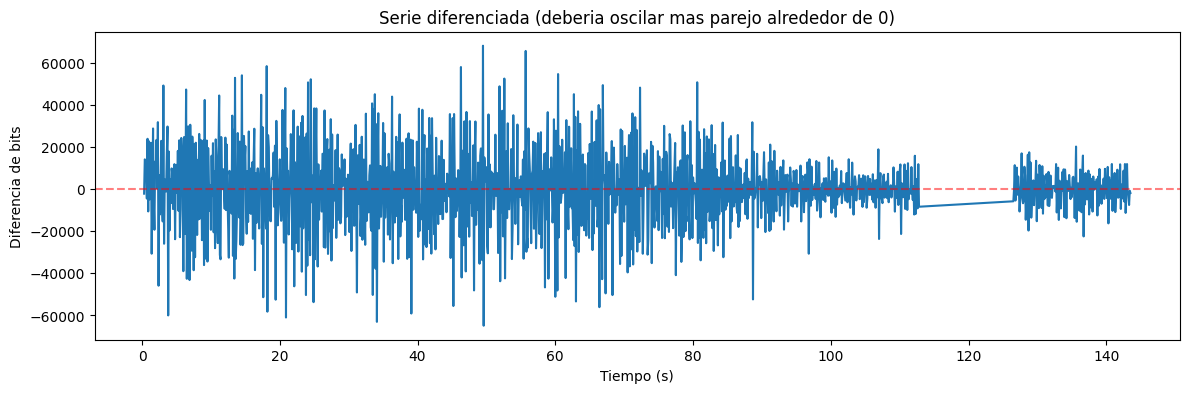

In [4]:
from sklearn.preprocessing import MinMaxScaler

# el paper usa diferenciacion "estacional" (24h) pero mi serie dura segundos, no dias
# entonces uso diferenciacion simple de primer orden, mismo objetivo: quitar el nivel y quedarme con el cambio
traffic_series["bits_diff"] = traffic_series["total_bits"].diff()
traffic_series_clean = traffic_series.dropna().reset_index(drop=True)

print("puntos despues de diferenciar:", len(traffic_series_clean))

# normalizo entre 0 y 1 como hace el paper
scaler = MinMaxScaler(feature_range=(0, 1))
traffic_series_clean["bits_norm"] = scaler.fit_transform(traffic_series_clean[["bits_diff"]])

plt.figure(figsize=(14, 4))
plt.plot(traffic_series_clean["time_bin"], traffic_series_clean["bits_diff"])
plt.axhline(0, color="red", linestyle="--", alpha=0.5)
plt.title("Serie diferenciada (deberia oscilar mas parejo alrededor de 0)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Diferencia de bits")
plt.show()

In [5]:
# separo 80/20 respetando el orden (nada de mezclar al azar en series de tiempo)
train_size = int(len(traffic_series_clean) * 0.8)
train_data = traffic_series_clean["bits_norm"].values[:train_size]
test_data = traffic_series_clean["bits_norm"].values[train_size:]

print("train:", len(train_data), "| test:", len(test_data))

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

# ventana de 10 pasos = 1 segundo de historia (cada paso es 0.1s) para predecir el siguiente
window_size = 10

X_train, y_train = create_sequences(train_data, window_size)
X_test, y_test = create_sequences(test_data, window_size)

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

train: 1037 | test: 260
X_train: (1027, 10, 1) | X_test: (250, 10, 1)


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

tf.random.set_seed(42)

def build_lstm():
    model = Sequential([
        LSTM(50, activation="tanh", input_shape=(window_size, 1)),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def build_gru():
    model = Sequential([
        GRU(50, activation="tanh", input_shape=(window_size, 1)),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

def build_cnn():
    model = Sequential([
        Conv1D(filters=32, kernel_size=3, activation="relu", input_shape=(window_size, 1)),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(50, activation="relu"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

results = {}

for name, builder in [("LSTM", build_lstm), ("GRU", build_gru), ("CNN", build_cnn)]:
    print(f"entrenando {name}...")
    model = builder()
    history = model.fit(X_train, y_train, epochs=20, batch_size=16,
                         validation_split=0.1, verbose=0)

    y_pred = model.predict(X_test, verbose=0).flatten()

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2, "model": model, "y_pred": y_pred}
    print(f"{name} -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

entrenando LSTM...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


LSTM -> RMSE: 0.0567, MAE: 0.0474, R²: 0.0739
entrenando GRU...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


GRU -> RMSE: 0.0563, MAE: 0.0472, R²: 0.0842
entrenando CNN...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN -> RMSE: 0.0565, MAE: 0.0468, R²: 0.0779


In [7]:
def build_slstm(hidden_units):
    model = Sequential([
        LSTM(hidden_units, activation="tanh", input_shape=(window_size, 1), return_sequences=True),
        LSTM(hidden_units // 2, activation="tanh"),
        Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

# mismo mecanismo adaptativo de antes: arranco chico y voy duplicando si mejora
hidden_units = 16
max_units = 128
threshold_improvement = 0.001
prev_val_loss = None
best_model = None
best_val_loss = np.inf

print("arrancando el ajuste adaptativo del SLSTM...\n")

while hidden_units <= max_units:
    print(f"probando con {hidden_units} unidades...")
    model = build_slstm(hidden_units)
    history = model.fit(X_train, y_train, epochs=15, batch_size=16,
                         validation_split=0.1, verbose=0)

    val_loss = min(history.history["val_loss"])
    print(f"  val_loss: {val_loss:.5f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model
        best_units = hidden_units

    if prev_val_loss is not None and (prev_val_loss - val_loss) < threshold_improvement:
        print("  mejora insuficiente, corto aca")
        break

    prev_val_loss = val_loss
    hidden_units *= 2

print(f"\nmejor arquitectura: {best_units} unidades (val_loss={best_val_loss:.5f})")

y_pred_slstm = best_model.predict(X_test, verbose=0).flatten()

rmse_slstm = np.sqrt(mean_squared_error(y_test, y_pred_slstm))
mae_slstm = mean_absolute_error(y_test, y_pred_slstm)
r2_slstm = r2_score(y_test, y_pred_slstm)

results["SLSTM"] = {"RMSE": rmse_slstm, "MAE": mae_slstm, "R2": r2_slstm,
                     "model": best_model, "y_pred": y_pred_slstm}

print(f"\nSLSTM -> RMSE: {rmse_slstm:.4f}, MAE: {mae_slstm:.4f}, R²: {r2_slstm:.4f}")

arrancando el ajuste adaptativo del SLSTM...

probando con 16 unidades...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  val_loss: 0.00307
probando con 32 unidades...
  val_loss: 0.00316
  mejora insuficiente, corto aca

mejor arquitectura: 16 unidades (val_loss=0.00307)



SLSTM -> RMSE: 0.0574, MAE: 0.0463, R²: 0.0478


         RMSE     MAE      R2
LSTM   0.0567  0.0474  0.0739
GRU    0.0563  0.0472  0.0842
CNN    0.0565  0.0468  0.0779
SLSTM  0.0574  0.0463  0.0478


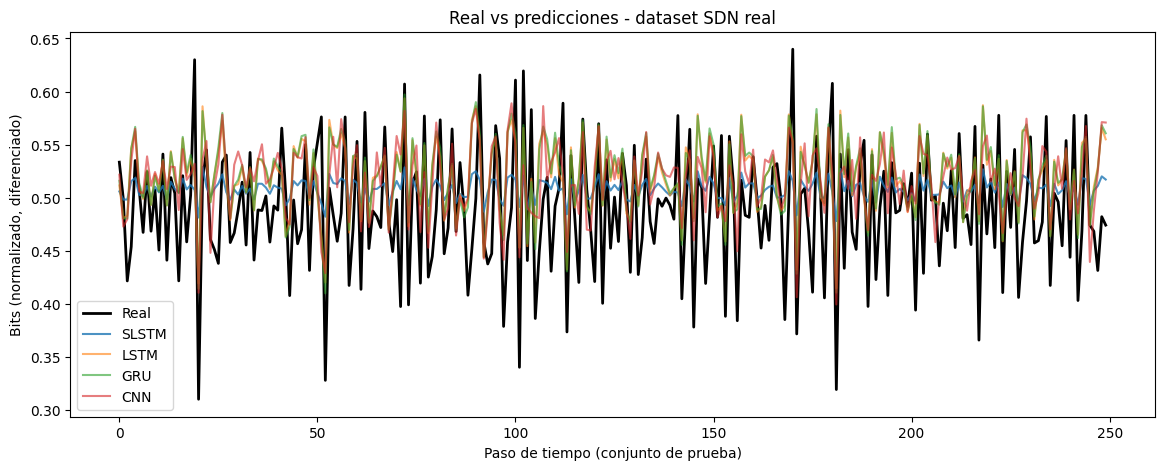

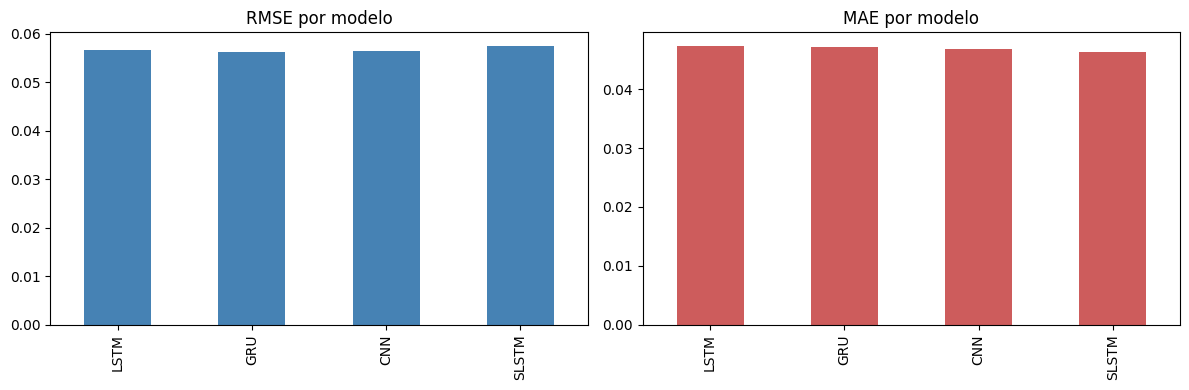

In [8]:
comparison_df = pd.DataFrame({
    name: {"RMSE": res["RMSE"], "MAE": res["MAE"], "R2": res["R2"]}
    for name, res in results.items()
}).T

print(comparison_df.round(4))

plt.figure(figsize=(14, 5))
plt.plot(y_test, label="Real", color="black", linewidth=2)
plt.plot(results["SLSTM"]["y_pred"], label="SLSTM", alpha=0.8)
plt.plot(results["LSTM"]["y_pred"], label="LSTM", alpha=0.6)
plt.plot(results["GRU"]["y_pred"], label="GRU", alpha=0.6)
plt.plot(results["CNN"]["y_pred"], label="CNN", alpha=0.6)
plt.legend()
plt.title("Real vs predicciones - dataset SDN real")
plt.xlabel("Paso de tiempo (conjunto de prueba)")
plt.ylabel("Bits (normalizado, diferenciado)")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
comparison_df["RMSE"].plot(kind="bar", ax=axes[0], color="steelblue", title="RMSE por modelo")
comparison_df["MAE"].plot(kind="bar", ax=axes[1], color="indianred", title="MAE por modelo")
plt.tight_layout()
plt.show()